In [1]:
import os
import json
import matplotlib.pyplot as plt
from matplotlib import font_manager
font_path = "/usr/share/fonts/truetype/msttcorefonts/Arial.ttf"
font_manager.fontManager.addfont(font_path)
plt.rcParams["font.family"] = "Arial"


Saved: figures/DFS0.80.pdf


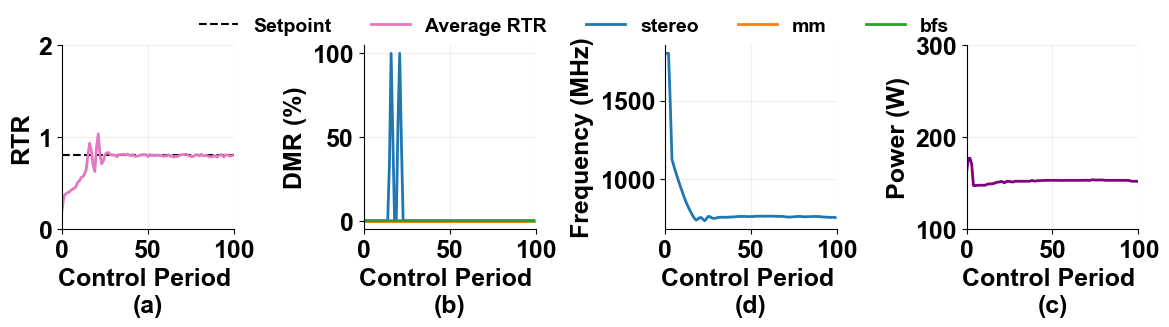

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --------- CONFIG ----------
root = Path("DFS_bounds/quasirand_converted_mm_converted_bfs_converted") 
root = Path("DFS_bounds/stereodisparity_converted_mm_converted_bfs_converted") 

setpoints = [0.80]
warmup_skip = 0          
max_periods = 100        
save_path = Path("figures")
save_path.mkdir(exist_ok=True)
labels = ["stereo", "mm", "bfs"]
task_colors = ['tab:blue', 'tab:orange', 'tab:red']

# Styling constants
FIGSIZE = (12, 3.5) 
TICK_FONTSIZE = 18
LINEWIDTH = 2.0
LABEL_FONTSIZE=18
# ---------------------------

def read_data(filepath: Path):
    if not filepath.exists():
        return None
    vals = []
    with filepath.open("r") as f:
        for line in f:
            s = line.strip()
            if not s: continue
            try:
                vals.append(float(s))
            except ValueError:
                continue
    return vals if vals else None

def slice_idx(data, start, stop):
    if data is None: return None
    n = len(data)
    a = min(max(start, 0), n)
    b = min(max(stop, 0), n)
    return np.asarray(data[a:b], dtype=float)

plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['Arial']})

for sp in setpoints:
    # UPDATED: Matches your directory listing with three setpoint values
    run_dir = root / f"setpoint_{sp:.2f}_{sp:.2f}_{sp:.2f}"
    
    idx_start, idx_stop = warmup_skip, max_periods
    
    # --- Configuration for 3 Tasks ---
    tasks = ["t1", "t2", "t3"]
    #labels = ["mm", "bfs", "hist"] # Renamed t3 to 'hist' based on your folder naming
    #colors = ['tab:blue', 'tab:orange', 'tab:red']
    
    # Data Dictionaries
    periods = {t: slice_idx(read_data(run_dir / f"DFS_{t}_period.txt"), idx_start, idx_stop) for t in tasks}
    deadlines = {t: slice_idx(read_data(run_dir / f"DFS_{t}_deadline.txt"), idx_start, idx_stop) for t in tasks}
    low_bounds = {t: slice_idx(read_data(run_dir / f"DFS_{t}_lowerperiodbound.txt"), idx_start, idx_stop) for t in tasks}
    high_bounds = {t: slice_idx(read_data(run_dir / f"DFS_{t}_higherperiodbound.txt"), idx_start, idx_stop) for t in tasks}
    
    # Global Metrics
    pwrs = slice_idx(read_data(run_dir / "DFS_finalpowervalues.txt"), idx_start, idx_stop)
    freq = slice_idx(read_data(run_dir / "DFS_finalfreqvalsvalues.txt"), idx_start, idx_stop)
    rtr_avg = slice_idx(read_data(run_dir / "DFSaveragertr.txt"), idx_start, idx_stop)

    #fig, axs = plt.subplots(1, 5, figsize=(16, 3.5))
    fig, axs = plt.subplots(1, 4, figsize=FIGSIZE)

    # (1) RTR
    ax = axs[0]
    ax.axhline(y=sp, color='black', linestyle='--', linewidth=1.5, label="Setpoint")
    if rtr_avg is not None:
        ax.plot(rtr_avg, linewidth=2, label="Average RTR", color='tab:pink')
    ax.set_ylabel("RTR", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_xlabel("Control Period \n(a)", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_ylim(0, 2.0) # Adjusted based on typical 0.90 setpoints

    # (2) Deadline (DMR)
    ax = axs[1]
    for i, t in enumerate(tasks):
        if deadlines[t] is not None:
            ax.plot(deadlines[t], linewidth=2, label=labels[i])
    ax.set_ylabel("DMR (%)", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_xlabel("Control Period \n(b)", fontsize=LABEL_FONTSIZE, fontweight='bold')
    # (4) Power
    
    ax = axs[2]
    if freq is not None:
        ax.plot(freq, linewidth=2)
    ax.set_ylabel("Frequency (MHz)", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_xlabel("Control Period \n(d)", fontsize=LABEL_FONTSIZE, fontweight='bold')
    
    ax = axs[3]
    if pwrs is not None:
        ax.plot(pwrs, linewidth=2, color='purple')
    ax.set_ylabel("Power (W)", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_xlabel("Control Period \n(c)", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_ylim([100,300])
    # (5) Frequency


    for ax in axs:
        ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
        for tick in ax.get_xticklabels(): tick.set_fontweight("bold")
        for tick in ax.get_yticklabels(): tick.set_fontweight("bold")
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(True, alpha=0.2)

    # Unified Legend
    handles, labels_leg = [], []
    for ax in axs:
        ax.set_xlim([0,100])
        h, l = ax.get_legend_handles_labels()
        for hh, ll in zip(h, l):
            if ll not in labels_leg:
                handles.append(hh)
                labels_leg.append(ll)
    
    #fig.legend(handles, labels_leg, loc='upper center', bbox_to_anchor=(0.5, 0.98),                ncol=len(labels_leg), frameon=False, fontsize=14)
    
    
    fig.legend(
        handles, 
        labels_leg, 
        loc='upper center', 
        bbox_to_anchor=(0.5, 0.95),  
        ncol=len(labels_leg), 
        frameon=False,
        # Move size inside prop to avoid it being overridden
        prop={'weight': 'bold', 'size': 14} 
    )   


    plt.tight_layout()
    plt.subplots_adjust(top=0.82) 
    out_file = save_path / f'DFS{sp:.2f}.pdf'
    plt.savefig(out_file, bbox_inches='tight')
    print(f"Saved: {out_file}")
    plt.show()

Saved: figures/DFS0.90.pdf


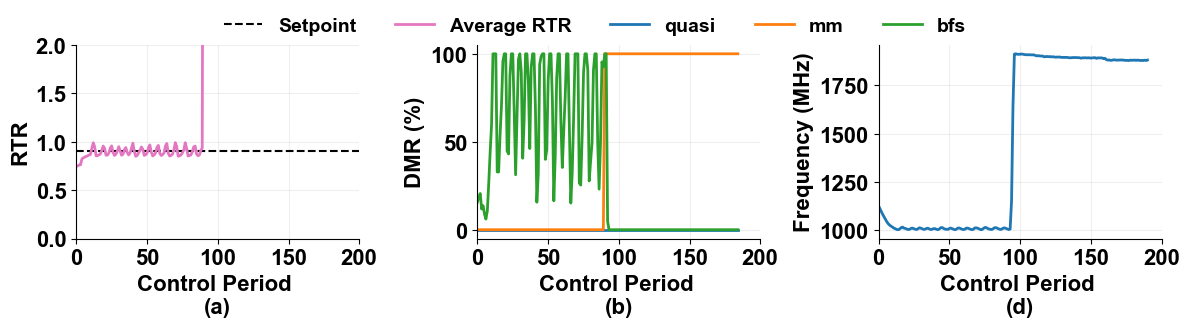

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --------- CONFIG ----------
root = Path("DFS_bounds/quasirand_converted_mm_converted_bfs_converted") 
root = Path("DFS_bounds1/quasirand_converted_mm_interrupt_bfs_converted") 

setpoints = [0.90]
warmup_skip = 5          
max_periods = 200        
save_path = Path("figures")
save_path.mkdir(exist_ok=True)
labels = ["quasi", "mm", "bfs"]
task_colors = ['tab:blue', 'tab:orange', 'tab:red']

# Styling constants
FIGSIZE = (12, 3.5) 
TICK_FONTSIZE = 16
LINEWIDTH = 2.0
LABEL_FONTSIZE=16
# ---------------------------

def read_data(filepath: Path):
    if not filepath.exists():
        return None
    vals = []
    with filepath.open("r") as f:
        for line in f:
            s = line.strip()
            if not s: continue
            try:
                vals.append(float(s))
            except ValueError:
                continue
    return vals if vals else None

def slice_idx(data, start, stop):
    if data is None: return None
    n = len(data)
    a = min(max(start, 0), n)
    b = min(max(stop, 0), n)
    return np.asarray(data[a:b], dtype=float)

plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['Arial']})

for sp in setpoints:
    # UPDATED: Matches your directory listing with three setpoint values
    run_dir = root / f"setpoint_{sp:.2f}_{sp:.2f}_{sp:.2f}"
    
    idx_start, idx_stop = warmup_skip, max_periods
    
    # --- Configuration for 3 Tasks ---
    tasks = ["t1", "t2", "t3"]
    #labels = ["mm", "bfs", "hist"] # Renamed t3 to 'hist' based on your folder naming
    #colors = ['tab:blue', 'tab:orange', 'tab:red']
    
    # Data Dictionaries
    periods = {t: slice_idx(read_data(run_dir / f"DFS_{t}_period.txt"), idx_start, idx_stop) for t in tasks}
    deadlines = {t: slice_idx(read_data(run_dir / f"DFS_{t}_deadline.txt"), idx_start, idx_stop) for t in tasks}
    low_bounds = {t: slice_idx(read_data(run_dir / f"DFS_{t}_lowerperiodbound.txt"), idx_start, idx_stop) for t in tasks}
    high_bounds = {t: slice_idx(read_data(run_dir / f"DFS_{t}_higherperiodbound.txt"), idx_start, idx_stop) for t in tasks}
    
    # Global Metrics
    pwrs = slice_idx(read_data(run_dir / "DFS_finalpowervalues.txt"), idx_start, idx_stop)
    freq = slice_idx(read_data(run_dir / "DFS_finalfreqvalsvalues.txt"), idx_start, idx_stop)
    rtr_avg = slice_idx(read_data(run_dir / "DFSaveragertr.txt"), idx_start, idx_stop)

    #fig, axs = plt.subplots(1, 5, figsize=(16, 3.5))
    fig, axs = plt.subplots(1, 3, figsize=FIGSIZE)

    # (1) RTR
    ax = axs[0]
    ax.axhline(y=sp, color='black', linestyle='--', linewidth=1.5, label="Setpoint")
    if rtr_avg is not None:
        ax.plot(rtr_avg, linewidth=2, label="Average RTR", color='tab:pink')
    ax.set_ylabel("RTR", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_xlabel("Control Period \n(a)", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_ylim(0, 2.0) # Adjusted based on typical 0.90 setpoints

    # (2) Deadline (DMR)
    ax = axs[1]
    for i, t in enumerate(tasks):
        if deadlines[t] is not None:
            ax.plot(deadlines[t], linewidth=2, label=labels[i])
    ax.set_ylabel("DMR (%)", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_xlabel("Control Period \n(b)", fontsize=LABEL_FONTSIZE, fontweight='bold')
    # (4) Power
    # ax = axs[2]
    # if pwrs is not None:
    #     ax.plot(pwrs, linewidth=2, color='purple')
    # ax.set_ylabel("Power (W)", fontsize=LABEL_FONTSIZE, fontweight='bold')
    # ax.set_xlabel("Control Period \n(c)", fontsize=LABEL_FONTSIZE, fontweight='bold')
    # ax.set_ylim([100,200])
    # (5) Frequency
    ax = axs[2]
    if freq is not None:
        ax.plot(freq, linewidth=2)
    ax.set_ylabel("Frequency (MHz)", fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_xlabel("Control Period \n(d)", fontsize=LABEL_FONTSIZE, fontweight='bold')

    for ax in axs:
        ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
        for tick in ax.get_xticklabels(): tick.set_fontweight("bold")
        for tick in ax.get_yticklabels(): tick.set_fontweight("bold")
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(True, alpha=0.2)

    # Unified Legend
    handles, labels_leg = [], []
    for ax in axs:
        ax.set_xlim([0,200])
        h, l = ax.get_legend_handles_labels()
        for hh, ll in zip(h, l):
            if ll not in labels_leg:
                handles.append(hh)
                labels_leg.append(ll)
    
    #fig.legend(handles, labels_leg, loc='upper center', bbox_to_anchor=(0.5, 0.98),                ncol=len(labels_leg), frameon=False, fontsize=14)
    
    
    fig.legend(
        handles, 
        labels_leg, 
        loc='upper center', 
        bbox_to_anchor=(0.5, 0.95),  
        ncol=len(labels_leg), 
        frameon=False,
        # Move size inside prop to avoid it being overridden
        prop={'weight': 'bold', 'size': 14} 
    )   


    plt.tight_layout()
    plt.subplots_adjust(top=0.82) 
    out_file = save_path / f'DFS{sp:.2f}.pdf'
    plt.savefig(out_file, bbox_inches='tight')
    print(f"Saved: {out_file}")
    plt.show()

Saved individual figures for setpoint 0.80 to figures


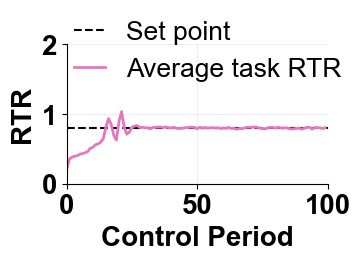

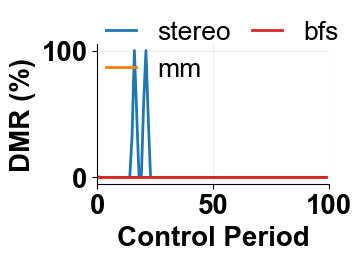

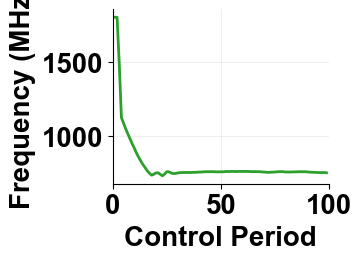

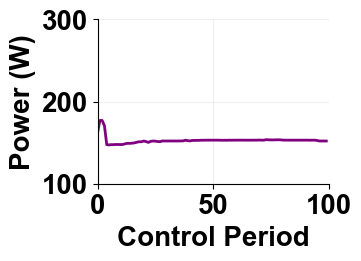

In [111]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --------- CONFIG ----------
root = Path("DFS_bounds/stereodisparity_converted_mm_converted_bfs_converted") 

setpoints = [0.80]
warmup_skip = 0          
max_periods = 100        
save_path = Path("figures")
save_path.mkdir(exist_ok=True)

# Task Configuration
tasks = ["t1", "t2", "t3"]
task_labels = ["stereo", "mm", "bfs"]
task_colors = ['tab:blue', 'tab:orange', 'tab:red']

# Styling constants
FIGSIZE = (3.5, 2.5) # Adjusted for single plot aspect ratio
TICK_FONTSIZE = 20
LABEL_FONTSIZE = 20
LINEWIDTH = 2.0
# ---------------------------

def read_data(filepath: Path):
    if not filepath.exists():
        return None
    vals = []
    with filepath.open("r") as f:
        for line in f:
            s = line.strip()
            if not s: continue
            try:
                vals.append(float(s))
            except ValueError:
                continue
    return vals if vals else None

def slice_idx(data, start, stop):
    if data is None: return None
    n = len(data)
    a = min(max(start, 0), n)
    b = min(max(stop, 0), n)
    return np.asarray(data[a:b], dtype=float)

def apply_styling(ax, xlabel, ylabel):
    """Applies consistent styling to an individual axis."""
    ax.set_xlabel(xlabel, fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
    for tick in ax.get_xticklabels(): tick.set_fontweight("bold")
    for tick in ax.get_yticklabels(): tick.set_fontweight("bold")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.2)
    ax.set_xlim([0, 100])

plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['Arial']})

for sp in setpoints:
    run_dir = root / f"setpoint_{sp:.2f}_{sp:.2f}_{sp:.2f}"
    idx_start, idx_stop = warmup_skip, max_periods
    
    # --- Load Data ---
    deadlines = {t: slice_idx(read_data(run_dir / f"DFS_{t}_deadline.txt"), idx_start, idx_stop) for t in tasks}
    pwrs = slice_idx(read_data(run_dir / "DFS_finalpowervalues.txt"), idx_start, idx_stop)
    freq = slice_idx(read_data(run_dir / "DFS_finalfreqvalsvalues.txt"), idx_start, idx_stop)
    rtr_avg = slice_idx(read_data(run_dir / "DFSaveragertr.txt"), idx_start, idx_stop)

    # 1. RTR FIGURE
    #fig,ax=plt.subplots(figsize=FIGSIZE)
    fig, ax = plt.subplots(figsize=FIGSIZE, layout="constrained")
    plt.axhline(y=sp, color='black', linestyle='--', linewidth=1.5, label="Set point")
    if rtr_avg is not None:
        plt.plot(rtr_avg, linewidth=LINEWIDTH, label="Average task RTR", color='tab:pink')
    apply_styling(plt.gca(), "Control Period", "RTR")
    plt.ylim(0, 2.0)
    ax.legend(
        frameon=False,          
        fancybox=False,        
        framealpha=0.4,        
        shadow=False,  
        fontsize=19,
        loc='upper center',
        # 0.5 centers it; 1.25 keeps it just above the plot
        bbox_to_anchor=(0.54, 1.25), 
        ncol=1,
        columnspacing=0.8,
        handlelength=1.15,
        borderaxespad=0. 
    )
    
    plt.savefig(save_path / f'DFS_{sp:.2f}_RTR.pdf', bbox_inches='tight')

    # 2. DEADLINE (DMR) FIGURE
    #fig,ax=plt.subplots(figsize=FIGSIZE)
    fig, ax = plt.subplots(figsize=FIGSIZE, layout="constrained")
    for i, t in enumerate(tasks):
        if deadlines[t] is not None:
            plt.plot(deadlines[t], linewidth=LINEWIDTH, label=task_labels[i], color=task_colors[i])
    apply_styling(plt.gca(), "Control Period", "DMR (%)")
    ax.legend(
        frameon=False,          
        fancybox=False,        
        framealpha=0.4,        
        shadow=False,  
        fontsize=19,
        loc='upper center',
        # 0.5 centers it; 1.25 keeps it just above the plot
        bbox_to_anchor=(0.54, 1.25), 
        ncol=2,
        columnspacing=0.8,
        handlelength=1.15,
        borderaxespad=0. 
    )
    plt.savefig(save_path / f'DFS_{sp:.2f}_DMR.pdf', bbox_inches='tight')

    # 3. FREQUENCY FIGURE
    fig, ax = plt.subplots(figsize=FIGSIZE, layout="constrained")
    if freq is not None:
        plt.plot(freq, linewidth=LINEWIDTH, color='tab:green')
    apply_styling(plt.gca(), "Control Period", "Frequency (MHz)")
    plt.savefig(save_path / f'DFS_{sp:.2f}_Freq.pdf', bbox_inches='tight')

    # 4. POWER FIGURE
    fig, ax = plt.subplots(figsize=FIGSIZE, layout="constrained")
    if pwrs is not None:
        plt.plot(pwrs, linewidth=LINEWIDTH, color='purple')
    apply_styling(plt.gca(), "Control Period", "Power (W)")
    plt.ylim([100, 300])
    plt.savefig(save_path / f'DFS_{sp:.2f}_Power.pdf', bbox_inches='tight')

    print(f"Saved individual figures for setpoint {sp:.2f} to {save_path}")

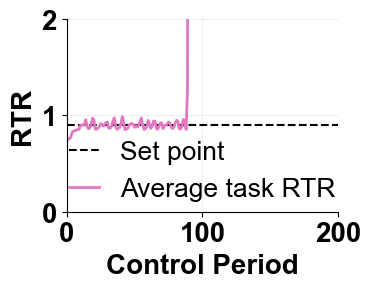

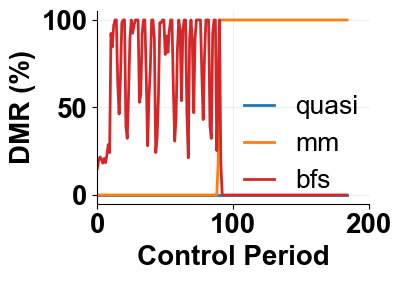

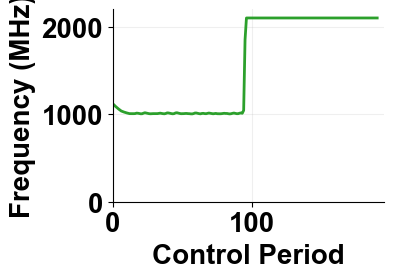

Individual plots for setpoint 0.90 saved to figures


In [118]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --------- CONFIG ----------
# Using your updated root and settings
root = Path("DFS_bounds1/quasirand_converted_mm_interrupt_bfs_converted") 

setpoints = [0.90]
warmup_skip = 5          
max_periods = 200        
save_path = Path("figures")
save_path.mkdir(exist_ok=True)

labels = ["quasi", "mm", "bfs"]
task_colors = ['tab:blue', 'tab:orange', 'tab:red']

# Individual Figure Styling
FIGSIZE = (3.5, 2.5) 
TICK_FONTSIZE = 20
LABEL_FONTSIZE = 20
LINEWIDTH = 2.0
# ---------------------------

def read_data(filepath: Path):
    if not filepath.exists(): return None
    vals = []
    with filepath.open("r") as f:
        for line in f:
            s = line.strip()
            if not s: continue
            try: vals.append(float(s))
            except ValueError: continue
    return vals if vals else None

def slice_idx(data, start, stop):
    if data is None: return None
    n = len(data)
    a = min(max(start, 0), n)
    b = min(max(stop, 0), n)
    return np.asarray(data[a:b], dtype=float)

def apply_common_style(ax, xlabel, ylabel):
    """Standardizes the look of each individual plot."""
    ax.set_xlabel(xlabel, fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
    for tick in ax.get_xticklabels(): tick.set_fontweight("bold")
    for tick in ax.get_yticklabels(): tick.set_fontweight("bold")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.2)
    ax.set_xlim([0, max_periods - warmup_skip])

plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['Arial']})

for sp in setpoints:
    run_dir = root / f"setpoint_{sp:.2f}_{sp:.2f}_{sp:.2f}"
    idx_start, idx_stop = warmup_skip, max_periods
    
    # Data Loading
    tasks = ["t1", "t2", "t3"]
    deadlines = {t: slice_idx(read_data(run_dir / f"DFS_{t}_deadline.txt"), idx_start, idx_stop) for t in tasks}
    freq = slice_idx(read_data(run_dir / "DFS_finalfreqvalsvalues.txt"), idx_start, idx_stop)
    rtr_avg = slice_idx(read_data(run_dir / "DFSaveragertr.txt"), idx_start, idx_stop)

    # --- 1. RTR FIGURE ---
    fig,ax=plt.subplots(figsize=FIGSIZE)
    plt.axhline(y=sp, color='black', linestyle='--', linewidth=1.5, label="Set point")
    if rtr_avg is not None:
        plt.plot(rtr_avg, linewidth=LINEWIDTH, label="Average task RTR", color='tab:pink')
    apply_common_style(plt.gca(), "Control Period", "RTR")
    plt.ylim(0, 2.0)
    plt.xlim(0,200)
    ax.legend(
        frameon=False,          
        fancybox=False,        
        framealpha=0.4,        
        shadow=False,  
        fontsize=19,
        loc='lower center',
        # 0.5 centers it; 1.25 keeps it just above the plot
        #bbox_to_anchor=(0.54, 1.25), 
        ncol=1,
        columnspacing=0.8,
        handlelength=1.15,
        borderaxespad=0. 
    )
    plt.savefig(save_path / f'DFS_{sp:.2f}_RTR.pdf', bbox_inches='tight')
    plt.show()

    # --- 2. DMR FIGURE ---
    fig,ax=plt.subplots(figsize=FIGSIZE)
    for i, t in enumerate(tasks):
        if deadlines[t] is not None:
            plt.plot(deadlines[t], linewidth=LINEWIDTH, label=labels[i], color=task_colors[i])
    apply_common_style(plt.gca(), "Control Period", "DMR (%)")
    plt.xlim(0,200)
    ax.legend(
        frameon=False,          
        fancybox=False,        
        framealpha=0.4,        
        shadow=False,  
        fontsize=19,
        loc='lower right',
        # 0.5 centers it; 1.25 keeps it just above the plot
       # bbox_to_anchor=(0.54, 1.25), 
        ncol=1,
        columnspacing=0.8,
        handlelength=1.15,
        borderaxespad=0. 
    )
    plt.savefig(save_path / f'DFS_{sp:.2f}_DMR.pdf', bbox_inches='tight')
    plt.show()

    # --- 3. FREQUENCY FIGURE ---
    plt.figure(figsize=FIGSIZE)
    if freq is not None:
        plt.plot(freq, linewidth=LINEWIDTH, color='tab:green')
    apply_common_style(plt.gca(), "Control Period", "Frequency (MHz)")
    plt.ylim(0, 2200.0)
    plt.savefig(save_path / f'DFS_{sp:.2f}_Freq.pdf', bbox_inches='tight')
    plt.show()

    print(f"Individual plots for setpoint {sp:.2f} saved to {save_path}")